## Класифікація Fashion-MNIST за допомогою Keras

Oпис датасету:
https://www.tensorflow.org/datasets/catalog/fashion_mnist

In [30]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)


### Завантаження та підготовка даних

In [31]:
from tensorflow.keras.datasets import fashion_mnist

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = fashion_mnist.load_data()

x_train_img = x_train_raw.copy()
x_test_img = x_test_raw.copy()

x_train_full = (x_train_raw.astype("float32") / 255.0).reshape(-1, 784)
x_test = (x_test_raw.astype("float32") / 255.0).reshape(-1, 784)


### Назви класів та приклади зображень

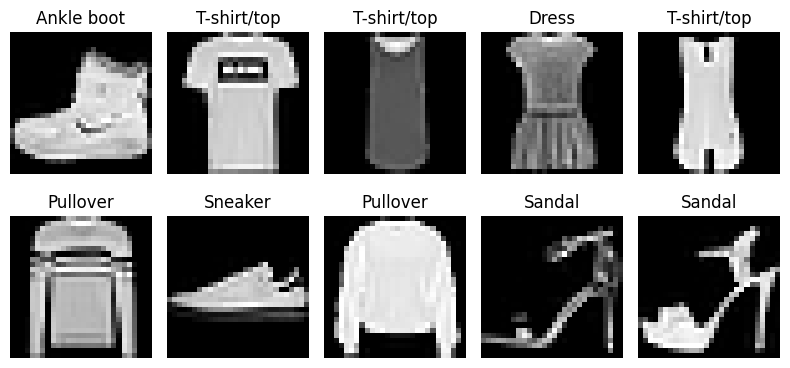

In [32]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_img[i], cmap="gray")
    plt.title(class_names[y_train_raw[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


### Коректний поділ на train / validation

In [33]:
n = x_train_full.shape[0]
val_size = 10000

idx = np.arange(n)
rng = np.random.default_rng(SEED)
rng.shuffle(idx)

val_idx = idx[:val_size]
train_idx = idx[val_size:]

x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]
x_val = x_train_full[val_idx]
y_val = y_train_full[val_idx]

### Модель


In [34]:
reg = tf.keras.regularizers.l2(1e-5)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.GaussianNoise(0.05),

    tf.keras.layers.Dense(512, activation="swish", kernel_initializer="he_normal", kernel_regularizer=reg),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Dense(256, activation="swish", kernel_initializer="he_normal", kernel_regularizer=reg),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.20),

    tf.keras.layers.Dense(128, activation="swish", kernel_initializer="he_normal", kernel_regularizer=reg),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.10),

    tf.keras.layers.Dense(64, activation="swish", kernel_initializer="he_normal", kernel_regularizer=reg),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.10),

    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)


### Callback-и
Використовуємо:
- `ModelCheckpoint`
- `EarlyStopping`
- `ReduceLROnPlateau`


In [35]:
callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath="best_fashion_dense.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=12,
            min_delta=0.0005,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1
        )
]

### Навчання моделі

In [36]:
history = model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=2,
    callbacks=callbacks
)

Epoch 1/40

Epoch 1: val_accuracy improved from None to 0.85250, saving model to best_fashion_dense.keras

Epoch 1: finished saving model to best_fashion_dense.keras
782/782 - 7s - 8ms/step - accuracy: 0.8069 - loss: 0.5679 - val_accuracy: 0.8525 - val_loss: 0.4173 - learning_rate: 8.0000e-04
Epoch 2/40

Epoch 2: val_accuracy improved from 0.85250 to 0.87130, saving model to best_fashion_dense.keras

Epoch 2: finished saving model to best_fashion_dense.keras
782/782 - 6s - 7ms/step - accuracy: 0.8513 - loss: 0.4299 - val_accuracy: 0.8713 - val_loss: 0.3685 - learning_rate: 8.0000e-04
Epoch 3/40

Epoch 3: val_accuracy did not improve from 0.87130
782/782 - 5s - 7ms/step - accuracy: 0.8657 - loss: 0.3925 - val_accuracy: 0.8669 - val_loss: 0.3790 - learning_rate: 8.0000e-04
Epoch 4/40

Epoch 4: val_accuracy improved from 0.87130 to 0.87950, saving model to best_fashion_dense.keras

Epoch 4: finished saving model to best_fashion_dense.keras
782/782 - 6s - 7ms/step - accuracy: 0.8740 - loss

### Аналіз навчання

In [37]:
best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
best_val_acc = float(np.max(history.history["val_accuracy"]))
best_train_acc = float(history.history["accuracy"][best_epoch - 1])

best_val_loss = float(np.min(history.history["val_loss"]))
best_train_loss = float(history.history["loss"][best_epoch - 1])

print("\n=== Найкраща епоха ===")
print(f"Епоха: {best_epoch}")
print(f"Validation accuracy: {best_val_acc:.4f}")
print(f"Train accuracy: {best_train_acc:.4f}")
print(f"Accuracy gap: {best_train_acc - best_val_acc:.4f}")


=== Найкраща епоха ===
Епоха: 24
Validation accuracy: 0.9084
Train accuracy: 0.9408
Accuracy gap: 0.0324


### Оцінка моделі на тестовій вибірці

In [38]:
best_model = tf.keras.models.load_model("best_fashion_dense.keras")
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

print("\n=== Test ===")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")



=== Test ===
Test accuracy: 0.8977
Test loss:     0.3403


### Криві навчання

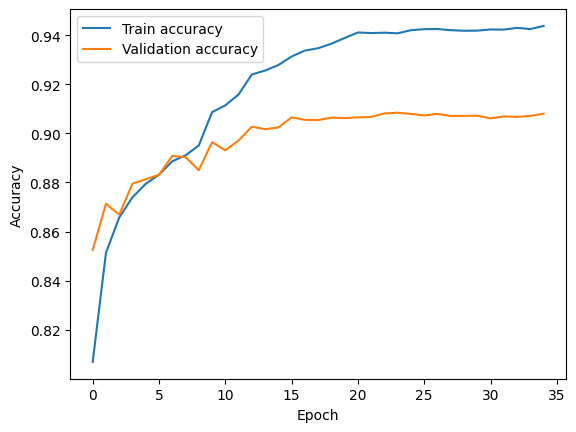

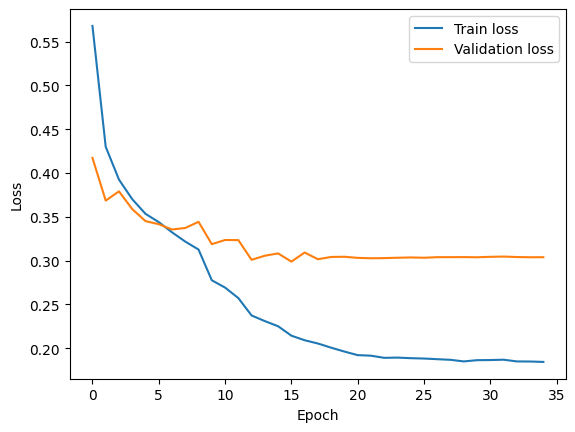

In [39]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


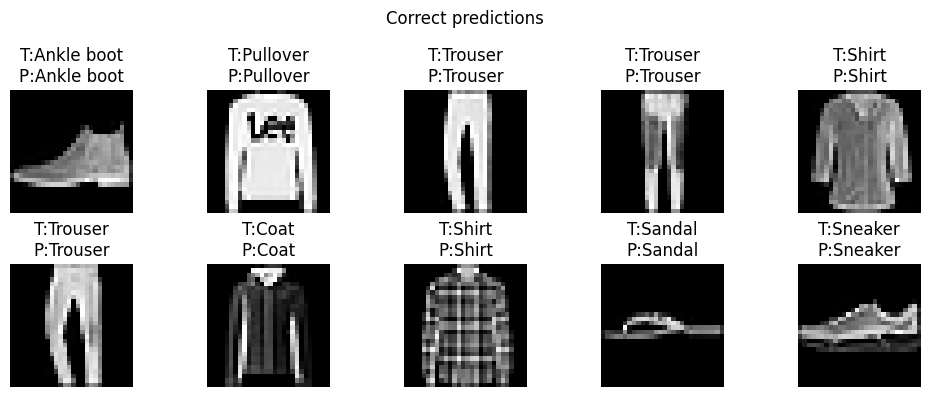

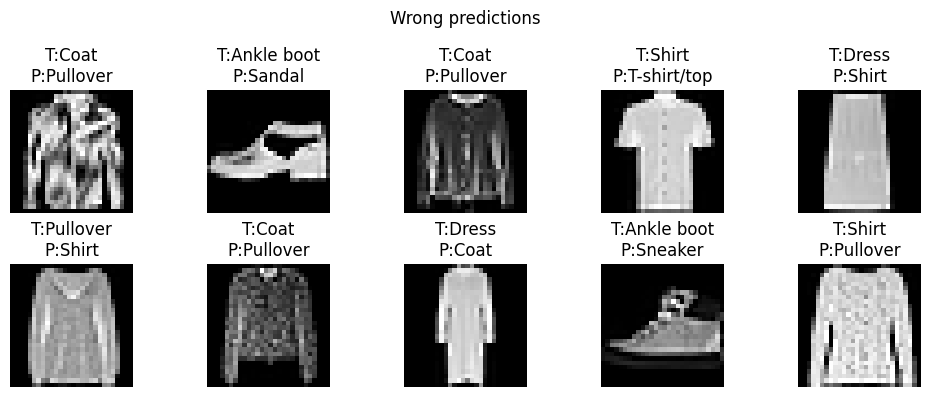

In [40]:
probs = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(probs, axis=1)
y_true = y_test_raw  # original integer labels

correct_idx = np.where(y_pred == y_true)[0]
wrong_idx = np.where(y_pred != y_true)[0]

def show_examples(indices, title, n=10):
    n = min(n, len(indices))
    plt.figure(figsize=(10, 4))
    for i in range(n):
        idx = indices[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test_img[idx], cmap="gray")
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(correct_idx, "Correct predictions", n=10)
show_examples(wrong_idx, "Wrong predictions", n=10)


## Висновки

У ході виконання роботи було побудовано та досліджено нейронну мережу **на основі повнозв’язних (Dense) шарів** для задачі класифікації зображень датасету **Fashion-MNIST** без використання згорткових шарів, що повністю відповідає умовам завдання.

### Якість моделі
- Найкраща валідаційна точність була досягнута на **24-й епосі** і становить **0.9084**, що знаходиться дуже близько до орієнтовного рівня **≈ 91%** для Dense-only архітектур.
- Точність на тренувальній вибірці становить **0.9408**, а розрив між train та validation accuracy дорівнює приблизно **0.03**.

### Аналіз процесу навчання
- Крива тренувальної точності зростає стабільно протягом навчання.
- Валідаційна точність після приблизно **20 епох** виходить на плато
- Відсутність різкого розходження між кривими train та validation підтверджує ефективність використаних методів регуляризації.

### Регуляризація та оптимізація
Для покращення стабільності навчання та зменшення перенавчання були застосовані такі підходи:
- **Dropout**
- **L2-регуляризація**
- **BatchNormalization**
- **GaussianNoise**
- callbacks **EarlyStopping**, **ModelCheckpoint** та **ReduceLROnPlateau**

